# First Goal Timing & Defeat Probability – Bundesliga

**Research Question:**  
Is there a relationship between when a team concedes its first lead-giving goal and whether they end up losing the match?




In [1]:
# Install and import libraries
!pip install requests pandas matplotlib scipy

import requests
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np
from scipy.stats import chi2_contingency


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\jakob\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
#load match data from the API
def get_matches(league, season):
    url = f'https://api.openligadb.de/getmatchdata/{league}/{season}'
    return requests.get(url).json()

LEAGUE  = 'bl1'
SEASONS = [2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]

all_matches = []
for season in SEASONS:
    matches = get_matches(LEAGUE, season)
    all_matches.extend(matches)

print(f'Total matches loaded: {len(all_matches)}')

Total matches loaded: 4896


In [3]:
#extract minute of first lead-giving goal + match outcome per team
records = []

for m in all_matches:
    if not m.get('matchIsFinished'):
        continue

    results = m.get('matchResults', [])
    ft = next((r for r in results if r['resultTypeID'] == 2), None)
    if not ft:
        continue

    goals = m.get('goals', [])
    if not goals:
        continue
    
    # final goals of team1 and team2
    ft1 = ft['pointsTeam1']
    ft2 = ft['pointsTeam2']

    #sort goals by the minute they were scored
    #if minute is missing -> push to end
    sorted_goals = sorted(goals, key=lambda x: x.get('matchMinute') or 999)

    score1, score2 = 0, 0
    #first minute when each team falls behind
    first_against_team1 = None
    first_against_team2 = None

    for g in sorted_goals:
        minute = g.get('matchMinute')
        if not minute or minute <= 0 or minute > 90:
            continue

        new_s1 = g.get('scoreTeam1', score1)
        new_s2 = g.get('scoreTeam2', score2)

        # Only count if this goal puts the opponent in the lead
        if new_s2 > score2 and new_s2 > new_s1 and first_against_team1 is None:
            first_against_team1 = minute
        if new_s1 > score1 and new_s1 > new_s2 and first_against_team2 is None:
            first_against_team2 = minute
        
        #update running score
        score1, score2 = new_s1, new_s2

    #determine match outcome if team 1 falls behind
    if first_against_team1:
        outcome = 'loss' if ft1 < ft2 else ('draw' if ft1 == ft2 else 'win')
        records.append({'minute': first_against_team1, 'outcome': outcome})

    if first_against_team2:
        outcome = 'loss' if ft2 < ft1 else ('draw' if ft1 == ft2 else 'win')
        records.append({'minute': first_against_team2, 'outcome': outcome})

df = pd.DataFrame(records)
print(f'Observations: {len(df)}')
df.head(10)

Observations: 5191


,minute,outcome
0,71,loss
1,75,loss
2,36,loss
3,6,loss
4,82,loss
5,43,draw
6,5,draw
7,25,draw
8,19,draw
9,3,draw


In [4]:
#group into 15-minute bins
bins   = [0, 15, 30, 45, 60, 75, 90]
labels = ['1-15', '16-30', '31-45', '46-60', '61-75', '76-90']

df['time_bin'] = pd.cut(df['minute'], bins=bins, labels=labels)
df['is_loss']  = df['outcome'] == 'loss'

#grouping count and mean of losses for each bin
bin_stats = df.groupby('time_bin', observed=True).agg(
    defeat_rate = ('is_loss', 'mean'),
    count       = ('is_loss', 'count')
).reset_index()
bin_stats['defeat_pct'] = (bin_stats['defeat_rate'] * 100).round(1)

#outcome distribution per bin
outcome_dist = (
    df.groupby(['time_bin', 'outcome'], observed=True)
    .size()
    .unstack(fill_value=0) #transform the result so that outcomes become columns
    .reindex(columns=['win', 'draw', 'loss'], fill_value=0)
)
#convert to percentage
outcome_pct = outcome_dist.div(outcome_dist.sum(axis=1), axis=0) * 100

print(bin_stats.to_string(index=False))

time_bin  defeat_rate  count  defeat_pct
    1-15     0.629700   1569        63.0
   16-30     0.675123   1222        67.5
   31-45     0.661238    921        66.1
   46-60     0.716049    648        71.6
   61-75     0.773756    442        77.4
   76-90     0.894602    389        89.5


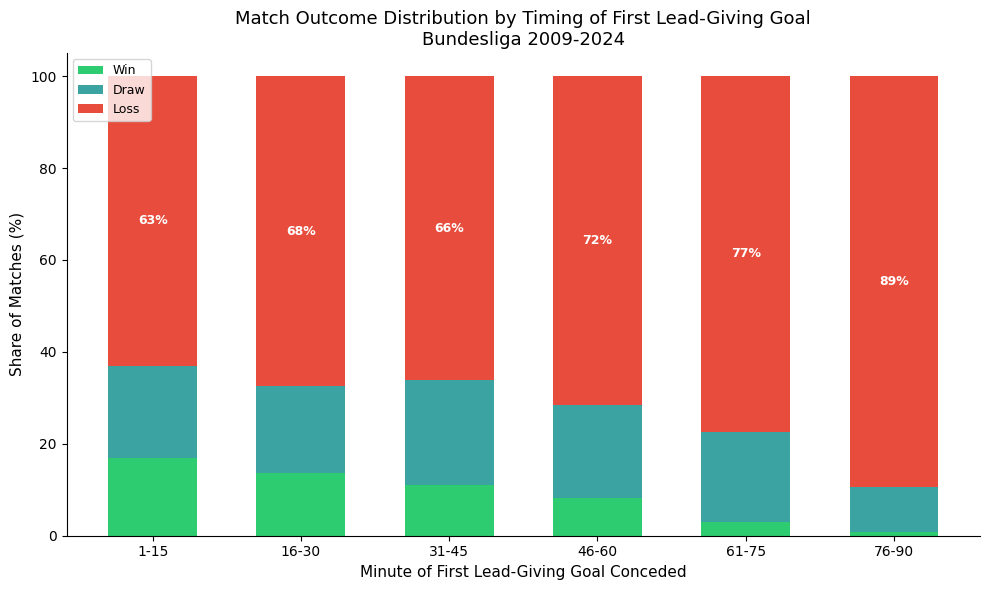

In [11]:
#figure:Stacked outcome distribution per time bin
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(outcome_pct))
win_vals  = outcome_pct['win'].values
draw_vals = outcome_pct['draw'].values
loss_vals = outcome_pct['loss'].values

ax.bar(x, win_vals,  label='Win',  color='#2ecc71', width=0.6)
ax.bar(x, draw_vals, label='Draw', color="#3ca3a3", width=0.6, bottom=win_vals)
ax.bar(x, loss_vals, label='Loss', color='#e74c3c', width=0.6, bottom=win_vals + draw_vals)

# Annotate loss % inside bar
for i, (w, d, l) in enumerate(zip(win_vals, draw_vals, loss_vals)):
    ax.text(i, w + d + l / 2, f'{l:.0f}%', ha='center', va='center',
            fontsize=9, color='white', fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(outcome_pct.index.astype(str))
ax.set_xlabel('Minute of First Lead-Giving Goal Conceded', fontsize=11)
ax.set_ylabel('Share of Matches (%)', fontsize=11)
ax.set_title('Match Outcome Distribution by Timing of First Lead-Giving Goal\nBundesliga 2009-2024', fontsize=13)
ax.set_ylim(0, 105)
ax.legend(loc='upper left', fontsize=9)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

## hypothesis test: Chi-square test

**Question** Is there a statistical significant correlation between time window, when the first lead giving goal is score, and the game outcome?

**H₀ (null hypothesis):** The outcome of the game (win/draw/loss) is independent of the time window in which the first goal is conceded.

**H₁ (alternative hypothessis):** There is a significant correlation between the time window of the first goal and the outcome of the game.

**Significance level:** α = 0.05

In [10]:
#contingency table: Time bins x Outcome
contingency_table = outcome_dist.values  

chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print("Chi-Squared Independecy test")
print(f"Chi-Square-statistic : {chi2:.4f}")
print(f"p-value         : {p_value:.6f}")
print(f"Degrees of Freedom : {dof}")


alpha = 0.05
if p_value < alpha:
    print(f"Decision: p = {p_value:.6f} < alpha = {alpha}")
    print("-> REJECT H₀.")
    print("Conclusion: There is a statistically significant correlation")
    print("between the time window of the first goal conceded and the")
    print("outcome of the game. Teams that fall behind later in the game lose more often.")
else:
    print(f"Entscheidung: p = {p_value:.6f} ≥ α = {alpha}")
    print("-> we cant reject H₀.")
    print("Conclusion: There is no significant correlation")


Chi-Squared Independecy test
Chi-Square-statistic : 180.8943
p-value         : 0.000000
Degrees of Freedom : 10
Decision: p = 0.000000 < alpha = 0.05
-> REJECT H₀.
Conclusion: There is a statistically significant correlation
between the time window of the first goal conceded and the
outcome of the game. Teams that fall behind later in the game lose more often.
